# 03 Event 2: 梅雨 (Plum Rain) 空間預測分析

**Part A: 空間預測對決**

本 Notebook 執行梅雨事件的完整空間分析流程，包含：
- A1: Variogram 分析與擬合
- A2: 四種內插法比較 (NN, IDW, Kriging, RF)
- A3: 差異圖與不確定性分析

備註：依作業規定，GeoTIFF 輸出僅需擇一事件完成，本腳本不包含 GeoTIFF 輸出。

輸入資料：`../data/processed/plumrain_rainfall.geojson` (EPSG:3826)

CELL 1: 資料讀取與網格建立
讀取資料筆數: 26
X 範圍: 276874 ~ 346034
Y 範圍: 2557832 ~ 2763948
Z 範圍: 0.50 ~ 4.00 mm

網格資訊:
  X 網格點數: 81
  Y 網格點數: 218
  總網格點數: 17658
  解析度: 1000m

✓ CELL 1 完成

CELL 2: A1 Variogram 分析與擬合
實驗變異圖計算完成，共 6 個 lag bins

擬合參數:
  Spherical - Sill: 0.5437, Range: 16560m, Nugget: 0.0355
  Exponential - Sill: 0.5457, Range: 398m, Nugget: 0.0335


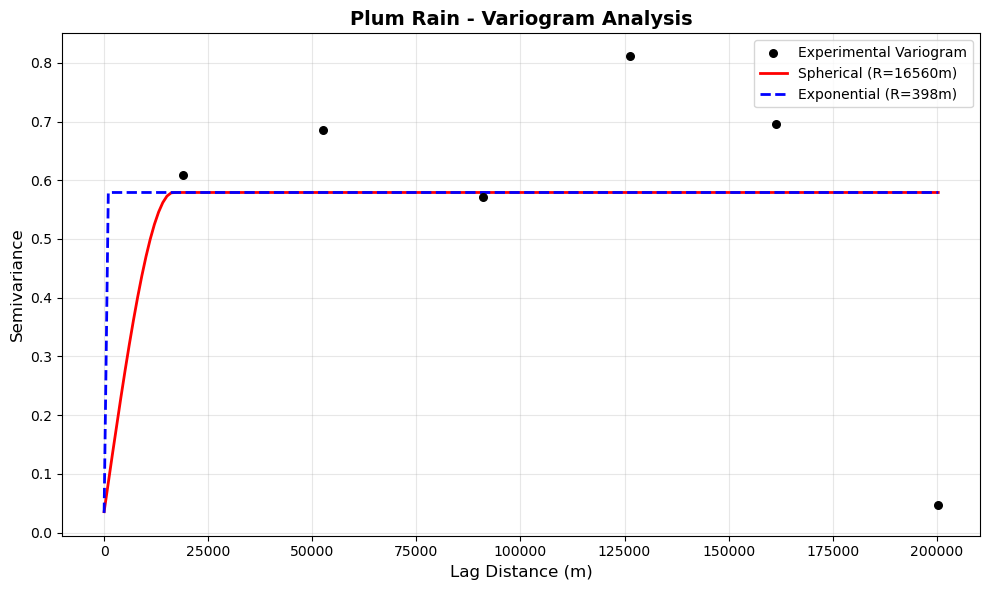


✓ 選定模型: SPHERICAL
  Sill: 0.5437
  Range: 16560 m
  Nugget: 0.0355

✓ CELL 2 完成

CELL 3: A2 四種內插法實作

[1/4] Nearest Neighbor 內插...
  完成 - 範圍: 0.50 ~ 4.00 mm

[2/4] IDW (power=2) 內插...
  完成 - 範圍: 0.50 ~ 3.99 mm

[3/4] Ordinary Kriging (spherical) 內插...
  完成 - 範圍: 0.33 ~ 3.47 mm

[4/4] Random Forest 內插...
  完成 - 範圍: 0.54 ~ 2.05 mm

繪製 2x2 比較圖...


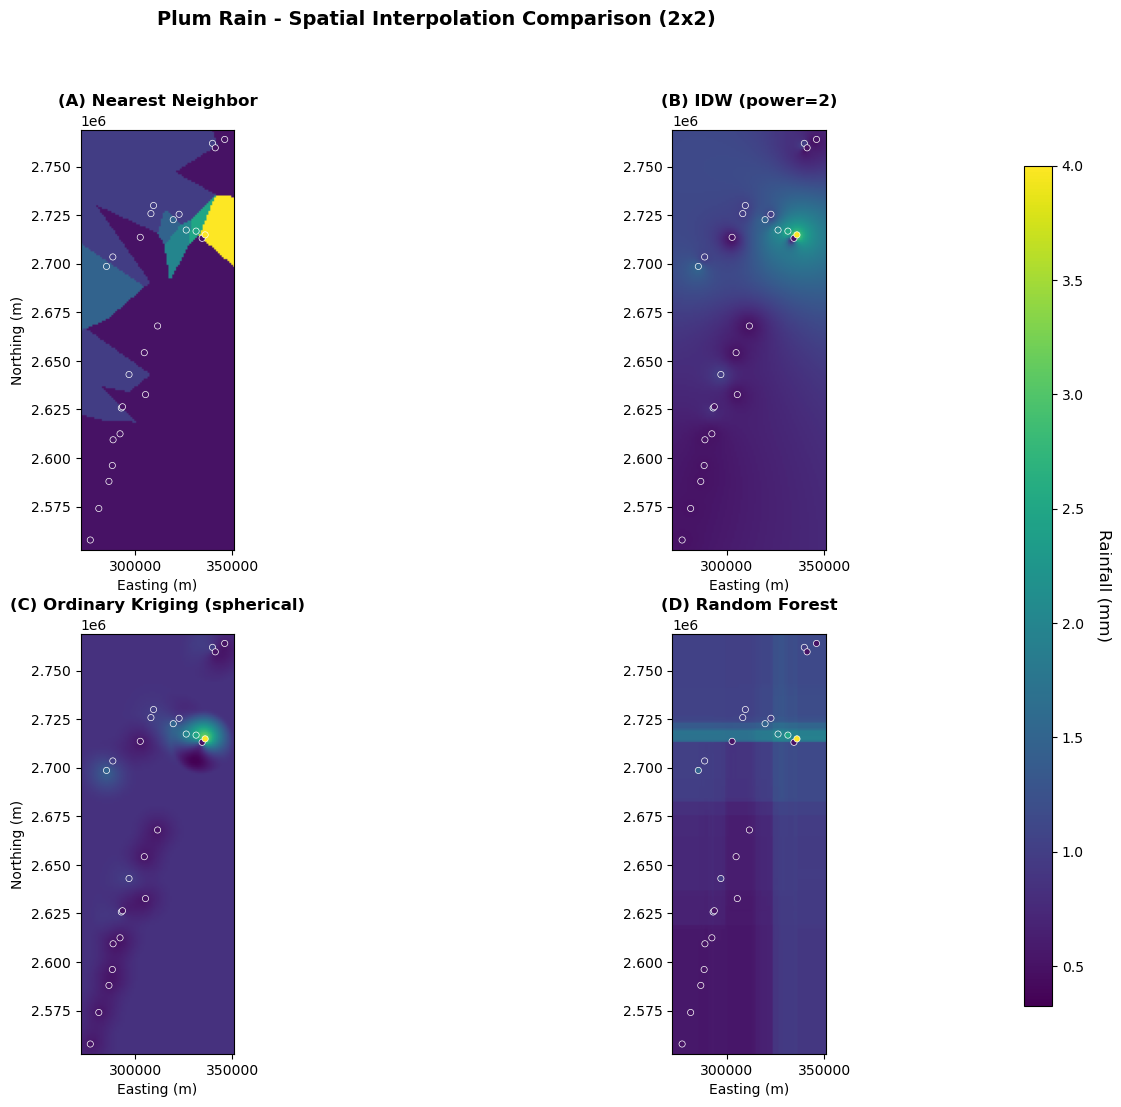

✓ 2x2 比較圖已儲存

✓ CELL 3 完成

CELL 4: A3 差異圖與不確定性分析

計算 Kriging 與 RF 差異...


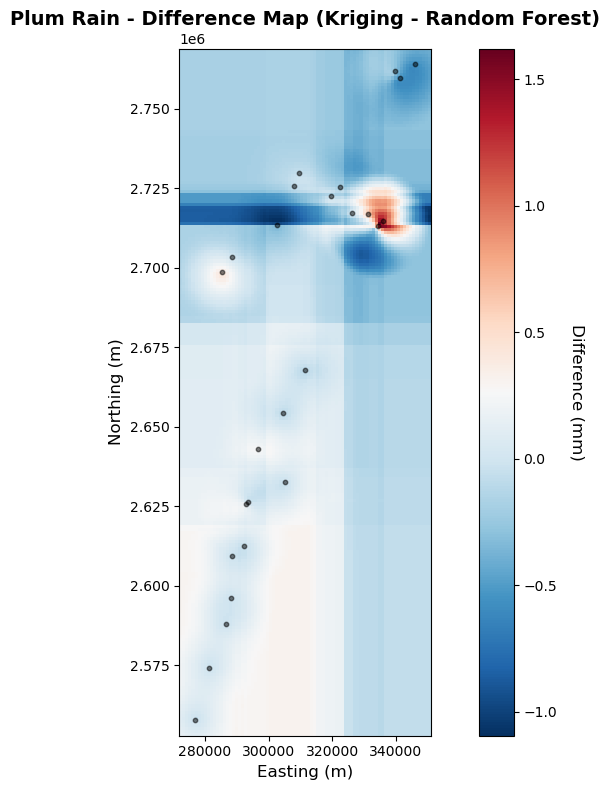

  差異範圍: -1.09 ~ 1.62 mm
  ✓ 差異圖已儲存

繪製 Kriging Sigma Map (不確定性地圖)...


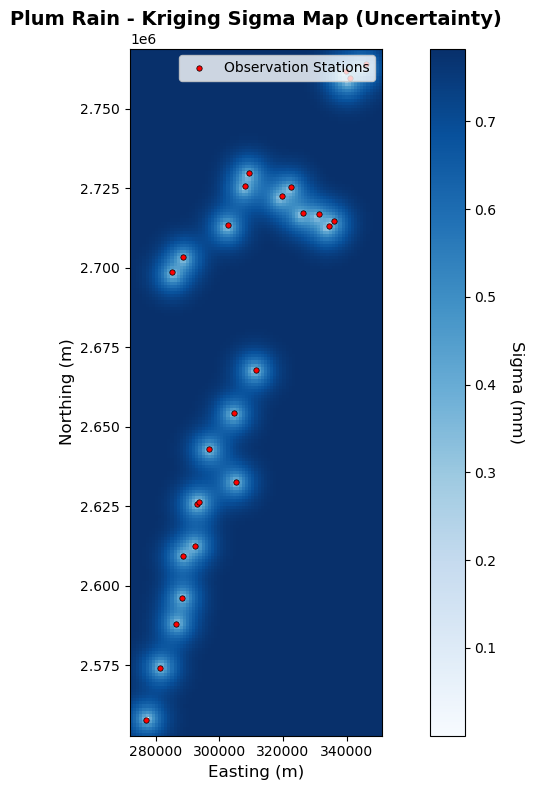

  Sigma 範圍: 0.00 ~ 0.78 mm
  ✓ Sigma Map 已儲存

✓ CELL 4 完成

梅雨事件分析全部完成!

輸出圖表 (../outputs/figures/):
  1. plumrain_variogram_comparison.png
  2. plumrain_interpolation_2x2_comparison.png
  3. plumrain_difference_kriging_rf.png
  4. plumrain_kriging_sigma_map.png

所有分析結果已儲存於 plumrain_results 字典中
可用變數數量: 27


In [1]:
# 執行完整分析腳本
%run plumrain_analysis.py

---

## 分析結果摘要

執行完成後，以下結果已產生：

### 圖表輸出 (../outputs/figures/)
- `plumrain_variogram_comparison.png` - Variogram 擬合比較圖
- `plumrain_interpolation_2x2_comparison.png` - 四種內插法 2x2 比較圖
- `plumrain_difference_kriging_rf.png` - Kriging vs RF 差異圖
- `plumrain_kriging_sigma_map.png` - Kriging 不確定性地圖

### 主要變數
執行後可在 Notebook 中存取：`plumrain_results` 字典包含所有分析結果

In [2]:
# 檢視可用結果變數
print('可用的分析結果:')
for key in plumrain_results.keys():
    print(f'  - {key}')

可用的分析結果:
  - X
  - Y
  - Z
  - grid_x
  - grid_y
  - grid_X
  - grid_Y
  - resolution
  - buffer
  - x_min
  - x_max
  - y_min
  - y_max
  - selected_model
  - spherical_params
  - exponential_params
  - lags
  - semivariance
  - Z_nn
  - Z_idw
  - Z_kriging
  - Z_rf
  - kriging_variance
  - vmin
  - vmax
  - diff_kriging_rf
  - sigma


---

## 跨事件比較 (選用)

若需比較凱米颱風與梅雨的差異，可同時載入兩事件結果：

In [3]:
# 比較兩事件的 Variogram 參數
print('='*60)
print('跨事件 Variogram 參數比較')
print('='*60)

try:
    # 確保已執行兩個分析腳本
    print('\n【凱米颱風】')
    print(f"  模型: {gaemi_results['selected_model']}")
    print(f"  Sill: {gaemi_results['spherical_params'][0]:.4f}")
    print(f"  Range: {gaemi_results['spherical_params'][1]:.0f} m")
    print(f"  Nugget: {gaemi_results['spherical_params'][2]:.4f}")
    
    print('\n【梅雨】')
    print(f"  模型: {plumrain_results['selected_model']}")
    print(f"  Sill: {plumrain_results['spherical_params'][0]:.4f}")
    print(f"  Range: {plumrain_results['spherical_params'][1]:.0f} m")
    print(f"  Nugget: {plumrain_results['spherical_params'][2]:.4f}")
except NameError as e:
    print('請先執行 gaemi_analysis.py 以載入 gaemi_results')
    print(f'錯誤: {e}')

跨事件 Variogram 參數比較

【凱米颱風】
請先執行 gaemi_analysis.py 以載入 gaemi_results
錯誤: name 'gaemi_results' is not defined
